# Titanic - Attempt 2
- **Autor:** Felipe Silva Loschi
- **Data:** abril/2026
- **Baseline (Attempt 1):** 0.77511 acurácia
- **Foco desta tentativa:** Feature Engineering adicionais, tentativa de novos modelos para verificar diferentes acurácias

> Como esta é uma continuação da tentativa anterior, insights, justificativas de escalonamento
> e Feature Engineering já documentados não serão repetidos — apenas as novidades serão detalhadas.

Importando as bibliotecas

In [81]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

Importando os dados

In [2]:
df = pd.read_csv('../../data/train.csv') #Estou rodando no VsCode, a importação pode variar de acordo com sua IDE
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## Feature Engineering

### Primeiro vou manter o que já havia feito

In [3]:
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.') #Esse é o Regex que extrai isso em Python
df['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [4]:
df['Title'] = df['Title'].replace({
    'Mlle':'Miss',
    'Mme':'Mrs',
    'Col':'Rare',
    'Major':'Rare',
    'Capt':'Rare',
    'Rev':'Rare',
    'Don': 'Rare',
    'Lady':'Rare',
    'Sir':'Rare',
    'the Countess':'Rare',
    'Jonkheer':'Rare'
})

Voltando a tentativa anterior, o título "Master" é usado para meninos jovens, então, quando for preencher valores nulos deles, posso colocar uma idade mais condizente que a mediana

Descobrindo quantos nulos serão tratados e as estatísticas antes

In [5]:
df[df['Title']=='Master']['Age'].isnull().sum()

np.int64(4)

In [6]:
df[df['Title']=='Master']['Age'].mean()

np.float64(4.574166666666667)

Tratando

In [7]:
df[df['Title']=='Master']['Age'].fillna(df[df['Title']=='Master']['Age'].median(), inplace=True)

C:\Users\lipe2\AppData\Local\Temp\ipykernel_32640\4083858519.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[df['Title']=='Master']['Age'].fillna(df[df['Title']=='Master']['Age'].median(), inplace=True)


Tá, vou ter que tratar de outra forma

In [8]:
df[(df['Title']=='Master') & (df['Age'].isna())]['Age'] = df[df['Title']=='Master']['Age'].median()

C:\Users\lipe2\AppData\Local\Temp\ipykernel_32640\3247680587.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[(df['Title']=='Master') & (df['Age'].isna())]['Age'] = df[df['Title']=='Master']['Age'].median()


Quase

In [9]:
df.loc[(df['Title']=='Master') & (df['Age'].isna()), 'Age'] = df[df['Title']=='Master']['Age'].median()

Agora sim, tive que usar '.loc[]' para acessar o dataframe original

In [10]:
df[df['Title']=='Master']['Age'].isnull().sum()

np.int64(0)

In [11]:
df[df['Title']=='Master']['Age'].mean()

np.float64(4.46675)

A média abaixou um pouco, o que é esperado, dado o valor que foi colocado onde era nulo ser 3.5, mas a Feature Engineering para esse caso agora foi mais bem feita.

Vou tratar o restante dos nulos da mesma forma que anteriormente

In [12]:
df["Age"].fillna(df["Age"].median(), inplace=True)
df["Cabin"].fillna("Unknown", inplace=True)
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

C:\Users\lipe2\AppData\Local\Temp\ipykernel_32640\1325268493.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
C:\Users\lipe2\AppData\Local\Temp\ipykernel_32640\1325268493.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [13]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
Title          0
dtype: int64

Tudo foi tratado.

### Novas Features Engineergings

#### Criando FamilySize

Continuando com as Feature Engineering, vou agora concatenar as colunas SibSp e Parch em uma única coluna. Dado que ambos falam sobre o tamanho da familia de uma pessoa, vou juntá-los em uma coluna chamada FamilySize e somar 1 nessa coluna, dado que SibSp e Parch me dão a informação apenas de quantos familiares a pessoa possuí, somando 1, ela mesma, eu tenho o tamanho da família.

In [14]:
df['FamilySize'] = df['Parch'] + df['SibSp'] + 1

### Criando GroupSize e FarePerPerson

Outra coisa que me incomodava um pouco na tentativa anterior eram os outliers presentes em Fare, aquele outlier da Pclass 1 principalmente. Vou dar uma investigada.

In [15]:
tickets = (df['Ticket'].value_counts() > 1)[df['Ticket'].value_counts() > 1].index
# O que a linha superior faz é muito simples, eu aplico uma
# máscara nela mesma, o que me retorna apenas os valores Trues
# da máscara e ao fazer .index, eu pego apenas os indexes dela.
# Em suma, eu estou pegando os tickets que foram usado por mais
# de uma pessoa, por ter descoberto que mais de uma pessoa usa o
# mesmo ticket dando uma olhada no Kaggle
df[df['Ticket'] == tickets[0]]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize
13,14,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,31.275,Unknown,S,Mr,7
119,120,0,3,"Andersson, Miss. Ellis Anna Maria",female,2.0,4,2,347082,31.275,Unknown,S,Miss,7
541,542,0,3,"Andersson, Miss. Ingeborg Constanzia",female,9.0,4,2,347082,31.275,Unknown,S,Miss,7
542,543,0,3,"Andersson, Miss. Sigrid Elisabeth",female,11.0,4,2,347082,31.275,Unknown,S,Miss,7
610,611,0,3,"Andersson, Mrs. Anders Johan (Alfrida Konstant...",female,39.0,1,5,347082,31.275,Unknown,S,Mrs,7
813,814,0,3,"Andersson, Miss. Ebba Iris Alfrida",female,6.0,4,2,347082,31.275,Unknown,S,Miss,7
850,851,0,3,"Andersson, Master. Sigvard Harald Elias",male,4.0,4,2,347082,31.275,Unknown,S,Master,7


A saída acima traz uma informação muito interessante, o valor de Fare na verdade não é o valor que uma pessoa pagou pelo Ticket, mas o valor  que o grupo inteiro pagou pelo Ticket. O que isso implica é que uma pessoa não pagou U$31.275 para estar no Titanic, mas uma família de 7 pessoas pagou isso no total, o que explica muitos outliers da coluna ['Fare']. Dito isso, posso fazer uma nova coluna para saber quanto cada pessoa pagou para estar lá e outra que agrupa as pessoas do mesmo Ticket, uma vez que essas pessoas podem não necessariamente ser família sendo diferente da coluna FamilySize criada anteriormente.

In [16]:
df['GroupSize'] = df['Ticket'].map(df['Ticket'].value_counts())
# O que a função acima faz é simples, o .map() usa os valores de
# linha do df['Ticket'] como chaves e procura o valor dessas chaves
# na Series que é retornada pelo df['Ticket']. value_counts(). Em
# suma, ele tá procurando por quantas pessoas cada Ticket foi usado

In [17]:
df['FarePerPerson'] = df['Fare']/df['GroupSize']

## Insights novos

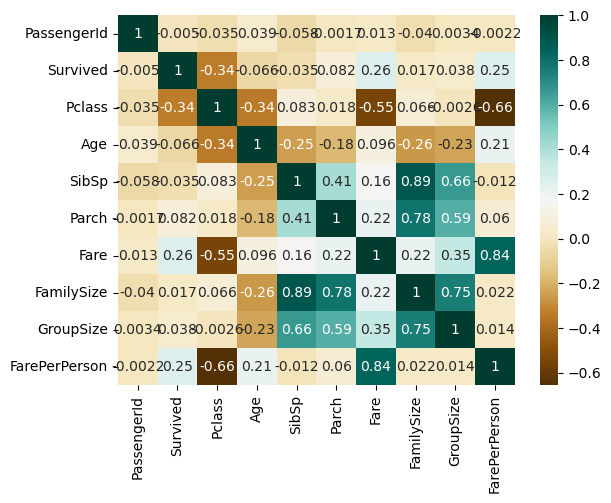

In [18]:
corr = df.corr(method="pearson", numeric_only=True)
plt.figure()
sns.heatmap(corr, cmap="BrBG", annot=True)
plt.show()

Analisando a matriz, percebe-se uma correlação alta entre SibSp e Parch e FamilySize, o que é normal dado que elas são parte da criação da coluna, e Fare e FarePerPerson, o que é dado pelo mesmo motivo. Além disso, percebemos que por mais que a correlação entre FamilySize e GroupSize seja muito alta, não é 1, o que atesta que ambas colunas são diferentes.

A correlação baixa entre FamilySize e GroupSize com sobrevivência me chamou atenção, vou explorar.

In [19]:
taxaDeSobrevivenciaGroupSize = df.groupby(['GroupSize'])['Survived'].mean()
taxaDeSobrevivenciaGroupSize

GroupSize
1    0.297989
2    0.574468
3    0.698413
4    0.500000
5    0.000000
6    0.000000
7    0.238095
Name: Survived, dtype: float64

In [20]:
taxaDeSobrevivenciaFamilySize = df.groupby(['FamilySize'])['Survived'].mean()
taxaDeSobrevivenciaFamilySize

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

Analisando ambos, percebemos que há um certo "ponto de virada" na taxa de sobrevivência de um grupo que é quando ele é maior que 4. Dito isso, vou fazer uma nova feature engineering para classificar grupos em "Grupos grandes", "Grupos pequenos" e "Viajando sozinho"

### Nova Feature Engineering

In [21]:
conditions = [
    df['GroupSize'] == 1,
    df['GroupSize'] <= 4,
    df['GroupSize'] > 4
]
choices = ['solo', 'pequeno', 'grande']
df['GroupSizeLabel'] = np.select(conditions, choices)

TypeError: Choicelist and default value do not have a common dtype: The DType <class 'numpy.dtypes._PyLongDType'> could not be promoted by <class 'numpy.dtypes.StrDType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes._PyLongDType'>)

In [22]:
df['GroupSize'].dtype

dtype('int64')

Como o tipo é int64 e todos os casos são cobertos no conditions, o possível erro é no default

In [23]:
conditions = [
    df['GroupSize'] == 1,
    df['GroupSize'] <= 4,
    df['GroupSize'] > 4
]
choices = ['solo', 'pequeno', 'grande']
df['GroupSizeLabel'] = np.select(conditions, choices, default='')

In [24]:
conditions = [
    df['FamilySize'] == 1,
    df['FamilySize'] <= 4,
    df['FamilySize'] > 4
]
choices = ['solo', 'pequeno', 'grande']
df['FamilySizeLabel'] = np.select(conditions, choices, default='')

Como mencionado antes no GroupSize e FamilySize, ambas colunas se complementam e não são redundantes, portanto é importante criar ambas.

## Treinando o Modelo
- Modelo: Em uma primeira tentativa, vou continuar com o Random Forest, mas também vou implementar XGBoost e o SVM dessa vez e vou tentar implementar uma ferramenta nova para mim, o StackingClassifier.

### Escalonamento
Primeiro, escalonamento. Colunas que vou usar:
- PassengerId: Não
- Name: Não
- Ticket: Não
- Cabin: Não
- Pclass: Sim
- Sex: Sim
- Age: Sim
- SibSp: Não(Informação já está em FamilySize)
- Parch: Não(Informação já está em FamilySize)
- FamilySize: Sim
- FamilySizeLabel: Sim
- GroupSize: Sim
- GroupSizeLabel: Sim
- Fare: Não, irei usar FarePerPerson
- FarePerPerson: Sim
- Embarked: Sim
- Title: Sim

In [ ]:
X = df.drop(columns=['Survived', 'SibSp', 'Parch', 'PassengerId',
                     'Name', 'Cabin', 'Ticket', 'Fare'], axis=1)
y = df['Survived']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
X_train.columns

Index(['Pclass', 'Sex', 'Age', 'Embarked', 'Title', 'FamilySize', 'GroupSize',
       'FarePerPerson', 'GroupSizeLabel', 'FamilySizeLabel'],
      dtype='object')

In [28]:
X.isna().sum()

Pclass             0
Sex                0
Age                0
Embarked           0
Title              0
FamilySize         0
GroupSize          0
FarePerPerson      0
GroupSizeLabel     0
FamilySizeLabel    0
dtype: int64

### Escalonamento para numéricos
- Padronização na variável nova e nas antigas
- Pclass continua sem escalonamento

### Escalonamento para não-numéricos
- Continua como antes

In [29]:
numeric_features = ['Age', 'FarePerPerson']
categorical_features = ['Sex', 'Embarked', 'Title', 'GroupSizeLabel', 'FamilySizeLabel']

In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop='first',handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' #Pra ele pegar o Pclass também
)

### Treinando os modelos

#### Treinando RandomForestClassifier

In [31]:
pipeline_rf = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier())
])

In [32]:
param_grid_rf = {
    'model__max_depth': [3, 4, 5, 6, 7],
    'model__n_estimators': [100, 200, 300],
    'model__min_samples_leaf': [2, 4, 6]
}

In [33]:
grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, refit=True, verbose=2)

In [34]:
X_train.isna().sum()

Pclass             0
Sex                0
Age                0
Embarked           0
Title              0
FamilySize         0
GroupSize          0
FarePerPerson      0
GroupSizeLabel     0
FamilySizeLabel    0
dtype: int64

In [35]:
grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 45 candidates, totalling 225 fits
[CV] END model__max_depth=3, model__min_samples_leaf=2, model__n_estimators=100; total time=   0.0s
[CV] END model__max_depth=3, model__min_samples_leaf=2, model__n_estimators=100; total time=   0.0s
[CV] END model__max_depth=3, model__min_samples_leaf=2, model__n_estimators=100; total time=   0.0s
[CV] END model__max_depth=3, model__min_samples_leaf=2, model__n_estimators=100; total time=   0.0s


c:\Users\lipe2\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


[CV] END model__max_depth=3, model__min_samples_leaf=2, model__n_estimators=100; total time=   0.0s
[CV] END model__max_depth=3, model__min_samples_leaf=2, model__n_estimators=200; total time=   0.1s
[CV] END model__max_depth=3, model__min_samples_leaf=2, model__n_estimators=200; total time=   0.1s
[CV] END model__max_depth=3, model__min_samples_leaf=2, model__n_estimators=200; total time=   0.1s


c:\Users\lipe2\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


[CV] END model__max_depth=3, model__min_samples_leaf=2, model__n_estimators=200; total time=   0.1s
[CV] END model__max_depth=3, model__min_samples_leaf=2, model__n_estimators=200; total time=   0.1s
[CV] END model__max_depth=3, model__min_samples_leaf=2, model__n_estimators=300; total time=   0.2s
[CV] END model__max_depth=3, model__min_samples_leaf=2, model__n_estimators=300; total time=   0.2s


...

[CV] END model__max_depth=7, model__min_samples_leaf=6, model__n_estimators=200; total time=   0.1s
[CV] END model__max_depth=7, model__min_samples_leaf=6, model__n_estimators=200; total time=   0.1s
[CV] END model__max_depth=7, model__min_samples_leaf=6, model__n_estimators=200; total time=   0.1s
[CV] END model__max_depth=7, model__min_samples_leaf=6, model__n_estimators=300; total time=   0.2s
[CV] END model__max_depth=7, model__min_samples_leaf=6, model__n_estimators=300; total time=   0.2s


c:\Users\lipe2\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


[CV] END model__max_depth=7, model__min_samples_leaf=6, model__n_estimators=300; total time=   0.2s
[CV] END model__max_depth=7, model__min_samples_leaf=6, model__n_estimators=300; total time=   0.2s
[CV] END model__max_depth=7, model__min_samples_leaf=6, model__n_estimators=300; total time=   0.2s


c:\Users\lipe2\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Age',
                                                                          'FarePerPerson']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['Sex',
                                                                          'Embarked',
                                                                          'Title',
                                                                          'GroupSizeLabel',
                                                                          'FamilySizeLabel'])])),
                                       ('model', RandomForestClassifier())]),
             param_grid={'model__max_depth': [3, 4, 5, 6, 7],
                         'model__min_samples_leaf': [2, 4, 6],
                         'model__n_estimators': [100, 200, 300]},
             verbose=2)

Ao invés de fazer os testes na mão dos hiperparâmetros, a função acima faz isso isso pra mim testando todas as combinações possíveis, o que cobre uma maior área de teste

In [36]:
print(f"Melhores parâmetros: {grid_rf.best_params_}")
print(f"Melhor resultado: {grid_rf.best_score_}")

Melhores parâmetros: {'model__max_depth': 6, 'model__min_samples_leaf': 4, 'model__n_estimators': 100}
Melhor resultado: 0.8370530877573131


In [37]:
y_train_predict = grid_rf.predict(X_train)
print(f"Acurácia do modelo: {accuracy_score(y_train, y_train_predict):.2f}")

Acurácia do modelo: 0.85


In [38]:
y_test_predict_rf = grid_rf.predict(X_test)
print(f"Acurácia do modelo: {accuracy_score(y_test, y_test_predict_rf):.2f}")

Acurácia do modelo: 0.83


#### Treinando XGBoost

In [39]:
pipeline_xg = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", XGBClassifier())
])

In [40]:
param_grid_xg = {
    'model__max_depth': [3, 4, 5, 6, 7],
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]
}

In [41]:
grid_xg = GridSearchCV(pipeline_xg, param_grid_xg, refit=True, verbose=2)

In [42]:
grid_xg.fit(X_train, y_train)

Fitting 5 folds for each of 75 candidates, totalling 375 fits
[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100; total time=   0.2s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100; total time=   0.0s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100; total time=   0.0s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100; total time=   0.0s


c:\Users\lipe2\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100; total time=   0.0s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=200; total time=   0.0s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=200; total time=   0.0s


c:\Users\lipe2\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=200; total time=   0.0s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=200; total time=   0.0s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=200; total time=   0.0s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=300; total time=   0.0s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=300; total time=   0.0s


...

[CV] END model__learning_rate=0.3, model__max_depth=7, model__n_estimators=200; total time=   0.1s
[CV] END model__learning_rate=0.3, model__max_depth=7, model__n_estimators=200; total time=   0.1s
[CV] END model__learning_rate=0.3, model__max_depth=7, model__n_estimators=200; total time=   0.1s
[CV] END model__learning_rate=0.3, model__max_depth=7, model__n_estimators=300; total time=   0.2s
[CV] END model__learning_rate=0.3, model__max_depth=7, model__n_estimators=300; total time=   0.2s


c:\Users\lipe2\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


[CV] END model__learning_rate=0.3, model__max_depth=7, model__n_estimators=300; total time=   0.1s
[CV] END model__learning_rate=0.3, model__max_depth=7, model__n_estimators=300; total time=   0.2s
[CV] END model__learning_rate=0.3, model__max_depth=7, model__n_estimators=300; total time=   0.1s


c:\Users\lipe2\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Age',
                                                                          'FarePerPerson']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['Sex',
                                                                          'Embarked',
                                                                          'Title',
                                                                          'GroupSizeLabel',
                                                                          'FamilySizeLabel'])])),
                                       ('model',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=No...
                                                      max_cat_to_onehot=None,
                                                      max_delta_step=None,
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             param_grid={'model__learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
                         'model__max_depth': [3, 4, 5, 6, 7],
                         'model__n_estimators': [100, 200, 300]},
             verbose=2)

In [43]:
print(f'Melhores parâmetros: {grid_xg.best_params_}')
print(f'Acurácia do modelo: {grid_xg.best_score_}')

Melhores parâmetros: {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 200}
Acurácia do modelo: 0.8300403821530582


In [44]:
y_test_predict_xg = grid_xg.predict(X_test)
print(f"Acurácia do modelo: {accuracy_score(y_test, y_test_predict_xg):.2f}")

Acurácia do modelo: 0.85


#### Treinando SVC

In [67]:
pipeline_svc = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", SVC(probability=True))
])

In [68]:
param_grid_svc = {
    'model__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'model__C': [0.1, 1, 10]
}

In [69]:
grid_svc = GridSearchCV(pipeline_svc, param_grid_svc, refit=True, verbose=2)

In [70]:
grid_svc.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END .................model__C=0.1, model__kernel=linear; total time=   0.0s
[CV] END .................model__C=0.1, model__kernel=linear; total time=   0.0s
[CV] END .................model__C=0.1, model__kernel=linear; total time=   0.0s
[CV] END .................model__C=0.1, model__kernel=linear; total time=   0.0s
[CV] END .................model__C=0.1, model__kernel=linear; total time=   0.0s


c:\Users\lipe2\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\lipe2\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


[CV] END ...................model__C=0.1, model__kernel=poly; total time=   0.0s
[CV] END ...................model__C=0.1, model__kernel=poly; total time=   0.0s
[CV] END ...................model__C=0.1, model__kernel=poly; total time=   0.0s
[CV] END ...................model__C=0.1, model__kernel=poly; total time=   0.0s
[CV] END ...................model__C=0.1, model__kernel=poly; total time=   0.0s
[CV] END ....................model__C=0.1, model__kernel=rbf; total time=   0.0s
[CV] END ....................model__C=0.1, model__kernel=rbf; total time=   0.0s
[CV] END ....................model__C=0.1, model__kernel=rbf; total time=   0.0s
[CV] END ....................model__C=0.1, model__kernel=rbf; total time=   0.0s
[CV] END ....................model__C=0.1, model__kernel=rbf; total time=   0.0s
[CV] END ................model__C=0.1, model__kernel=sigmoid; total time=   0.0s


c:\Users\lipe2\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


[CV] END ................model__C=0.1, model__kernel=sigmoid; total time=   0.0s
[CV] END ................model__C=0.1, model__kernel=sigmoid; total time=   0.0s
[CV] END ................model__C=0.1, model__kernel=sigmoid; total time=   0.0s
[CV] END ................model__C=0.1, model__kernel=sigmoid; total time=   0.0s
[CV] END ...................model__C=1, model__kernel=linear; total time=   0.0s


...

[CV] END .....................model__C=10, model__kernel=rbf; total time=   0.0s
[CV] END .....................model__C=10, model__kernel=rbf; total time=   0.0s
[CV] END .....................model__C=10, model__kernel=rbf; total time=   0.0s
[CV] END .....................model__C=10, model__kernel=rbf; total time=   0.0s
[CV] END .....................model__C=10, model__kernel=rbf; total time=   0.0s


c:\Users\lipe2\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\lipe2\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


[CV] END .................model__C=10, model__kernel=sigmoid; total time=   0.0s
[CV] END .................model__C=10, model__kernel=sigmoid; total time=   0.0s
[CV] END .................model__C=10, model__kernel=sigmoid; total time=   0.0s
[CV] END .................model__C=10, model__kernel=sigmoid; total time=   0.0s
[CV] END .................model__C=10, model__kernel=sigmoid; total time=   0.0s


c:\Users\lipe2\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Age',
                                                                          'FarePerPerson']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['Sex',
                                                                          'Embarked',
                                                                          'Title',
                                                                          'GroupSizeLabel',
                                                                          'FamilySizeLabel'])])),
                                       ('model', SVC(probability=True))]),
             param_grid={'model__C': [0.1, 1, 10],
                         'model__kernel': ['linear', 'poly', 'rbf', 'sigmoid']},
             verbose=2)

In [71]:
print(f'Melhores parâmetros: {grid_svc.best_params_}')
print(f'Melhor resultado: {grid_svc.best_score_}')

Melhores parâmetros: {'model__C': 1, 'model__kernel': 'poly'}
Melhor resultado: 0.8328277356446371


In [72]:
y_test_predict_svc = grid_svc.predict(X_test)
print(f"Acurácia do modelo: {accuracy_score(y_test, y_test_predict_svc):.2f}")

Acurácia do modelo: 0.83


### Treinando o Voting Classifier

In [73]:
voting_hard = VotingClassifier(estimators = 
                          [('rf', grid_rf.best_estimator_),
                           ('xg', grid_xg.best_estimator_),
                           ('svc', grid_svc.best_estimator_)],
                           voting = "hard")

In [74]:
voting_hard.fit(X_train, y_train)

VotingClassifier(estimators=[('rf',
                              Pipeline(steps=[('preprocessing',
                                               ColumnTransformer(remainder='passthrough',
                                                                 transformers=[('num',
                                                                                StandardScaler(),
                                                                                ['Age',
                                                                                 'FarePerPerson']),
                                                                               ('cat',
                                                                                OneHotEncoder(drop='first',
                                                                                              handle_unknown='ignore'),
                                                                                ['Sex',
                                                                                 'Embarked',
                                                                                 'Title',
                                                                                 'GroupSizeLabel',
                                                                                 'FamilySizeLabel'])])),
                                              ('model',
                                               RandomForestClassifier(max_depth=6,
                                                                      min_samp...
                                                             num_parallel_tree=None, ...))])),
                             ('svc',
                              Pipeline(steps=[('preprocessing',
                                               ColumnTransformer(remainder='passthrough',
                                                                 transformers=[('num',
                                                                                StandardScaler(),
                                                                                ['Age',
                                                                                 'FarePerPerson']),
                                                                               ('cat',
                                                                                OneHotEncoder(drop='first',
                                                                                              handle_unknown='ignore'),
                                                                                ['Sex',
                                                                                 'Embarked',
                                                                                 'Title',
                                                                                 'GroupSizeLabel',
                                                                                 'FamilySizeLabel'])])),
                                              ('model',
                                               SVC(C=1, kernel='poly',
                                                   probability=True))]))])

In [75]:
y_test_predict_hard = voting_hard.predict(X_test)
print(f"Acurácia do modelo: {accuracy_score(y_test, y_test_predict_hard):.2f}")

Acurácia do modelo: 0.83


In [76]:
voting_soft = VotingClassifier(estimators = 
                          [('rf', grid_rf.best_estimator_),
                           ('xg', grid_xg.best_estimator_),
                           ('svc', grid_svc.best_estimator_)],
                           voting = 'soft')

In [77]:
voting_soft.fit(X_train,y_train)

VotingClassifier(estimators=[('rf',
                              Pipeline(steps=[('preprocessing',
                                               ColumnTransformer(remainder='passthrough',
                                                                 transformers=[('num',
                                                                                StandardScaler(),
                                                                                ['Age',
                                                                                 'FarePerPerson']),
                                                                               ('cat',
                                                                                OneHotEncoder(drop='first',
                                                                                              handle_unknown='ignore'),
                                                                                ['Sex',
                                                                                 'Embarked',
                                                                                 'Title',
                                                                                 'GroupSizeLabel',
                                                                                 'FamilySizeLabel'])])),
                                              ('model',
                                               RandomForestClassifier(max_depth=6,
                                                                      min_samp...
                                                             num_parallel_tree=None, ...))])),
                             ('svc',
                              Pipeline(steps=[('preprocessing',
                                               ColumnTransformer(remainder='passthrough',
                                                                 transformers=[('num',
                                                                                StandardScaler(),
                                                                                ['Age',
                                                                                 'FarePerPerson']),
                                                                               ('cat',
                                                                                OneHotEncoder(drop='first',
                                                                                              handle_unknown='ignore'),
                                                                                ['Sex',
                                                                                 'Embarked',
                                                                                 'Title',
                                                                                 'GroupSizeLabel',
                                                                                 'FamilySizeLabel'])])),
                                              ('model',
                                               SVC(C=1, kernel='poly',
                                                   probability=True))]))],
                 voting='soft')

In [78]:
y_test_predict_soft = voting_soft.predict(X_test)
print(f"Acurácia do modelo: {accuracy_score(y_test, y_test_predict_soft):.2f}")

Acurácia do modelo: 0.83


### Treinando Stacking Classifier

In [82]:
base_learners = [
    ('rf', grid_rf.best_estimator_),
    ('xg', grid_xg.best_estimator_),
    ('svc', grid_svc.best_estimator_)
]
meta_model = LogisticRegression()

stacking_model = StackingClassifier(estimators=base_learners, final_estimator=meta_model)

In [83]:
stacking_model.fit(X_train, y_train)

c:\Users\lipe2\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\lipe2\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\lipe2\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


StackingClassifier(estimators=[('rf',
                                Pipeline(steps=[('preprocessing',
                                                 ColumnTransformer(remainder='passthrough',
                                                                   transformers=[('num',
                                                                                  StandardScaler(),
                                                                                  ['Age',
                                                                                   'FarePerPerson']),
                                                                                 ('cat',
                                                                                  OneHotEncoder(drop='first',
                                                                                                handle_unknown='ignore'),
                                                                                  ['Sex',
                                                                                   'Embarked',
                                                                                   'Title',
                                                                                   'GroupSizeLabel',
                                                                                   'FamilySizeLabel'])])),
                                                ('model',
                                                 RandomForestClassifier(max_depth=6,
                                                                        min_sa...
                                Pipeline(steps=[('preprocessing',
                                                 ColumnTransformer(remainder='passthrough',
                                                                   transformers=[('num',
                                                                                  StandardScaler(),
                                                                                  ['Age',
                                                                                   'FarePerPerson']),
                                                                                 ('cat',
                                                                                  OneHotEncoder(drop='first',
                                                                                                handle_unknown='ignore'),
                                                                                  ['Sex',
                                                                                   'Embarked',
                                                                                   'Title',
                                                                                   'GroupSizeLabel',
                                                                                   'FamilySizeLabel'])])),
                                                ('model',
                                                 SVC(C=1, kernel='poly',
                                                     probability=True))]))],
                   final_estimator=LogisticRegression())

In [84]:
y_test_predict_stacking = stacking_model.predict(X_test)
print(f"Acurácia do modelo: {accuracy_score(y_test, y_test_predict_stacking):.2f}")

Acurácia do modelo: 0.83


Olhando isoladamente, o XGBoost teve um melhor desempenho local, hora de submeter ele.
## Dataset de Test

In [85]:
df_test = pd.read_csv('../../data/test.csv')

Fazendo as transformações

In [88]:
df_test.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [91]:
df_test[df_test['Fare'].isna()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
152,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [92]:
df_test['Fare'].fillna(df_test[df_test['Pclass']==3]['Fare'].median(), inplace=True)

C:\Users\lipe2\AppData\Local\Temp\ipykernel_32640\2352949255.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test['Fare'].fillna(df_test[df_test['Pclass']==3]['Fare'].median(), inplace=True)


In [97]:
df_test['Title'] = df_test['Name'].str.extract(r',\s*([^\.]+)\.') #Esse é o Regex que extrai isso em Python
df_test['Title'] = df_test['Title'].replace({
    'Mlle':'Miss',
    'Mme':'Mrs',
    'Col':'Rare',
    'Major':'Rare',
    'Capt':'Rare',
    'Rev':'Rare',
    'Don': 'Rare',
    'Lady':'Rare',
    'Sir':'Rare',
    'the Countess':'Rare',
    'Jonkheer':'Rare',
    'Dona':'Rare'
})

df_test.loc[(df_test['Title']=='Master') & (df_test['Age'].isna()), 'Age'] = df_test[df_test['Title']=='Master']['Age'].median()

df_test["Age"].fillna(df["Age"].median(), inplace=True)
df_test["Cabin"].fillna("Unknown", inplace=True)

C:\Users\lipe2\AppData\Local\Temp\ipykernel_32640\1797145782.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test["Age"].fillna(df["Age"].median(), inplace=True)
C:\Users\lipe2\AppData\Local\Temp\ipykernel_32640\1797145782.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

In [98]:
df_test.isna().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
Title          0
dtype: int64

In [99]:
df_test['FamilySize'] = df_test['Parch'] + df_test['SibSp'] + 1

tickets = (df_test['Ticket'].value_counts() > 1)[df_test['Ticket'].value_counts() > 1].index
df_test['GroupSize'] = df_test['Ticket'].map(df_test['Ticket'].value_counts())

df_test['FarePerPerson'] = df_test['Fare']/df_test['GroupSize']

conditions = [
    df_test['GroupSize'] == 1,
    df_test['GroupSize'] <= 4,
    df_test['GroupSize'] > 4
]
choices = ['solo', 'pequeno', 'grande']
df_test['GroupSizeLabel'] = np.select(conditions, choices, default='')

conditions = [
    df_test['FamilySize'] == 1,
    df_test['FamilySize'] <= 4,
    df_test['FamilySize'] > 4
]
choices = ['solo', 'pequeno', 'grande']
df_test['FamilySizeLabel'] = np.select(conditions, choices, default='')

In [100]:
X_test = df_test.drop(columns=['SibSp', 'Parch', 'PassengerId',
                     'Name', 'Cabin', 'Ticket', 'Fare'], axis=1)

### XGBoost

In [101]:
df_resposta = pd.DataFrame({'PassengerId' : df_test['PassengerId'],
                           'Survived' : grid_xg.predict(X_test)})

In [102]:
df_resposta.to_csv('Resposta_xg.csv', index=False)

In [103]:
df_resposta

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


### Random Forest

In [104]:
df_resposta_rf = pd.DataFrame({'PassengerId' : df_test['PassengerId'],
                           'Survived' : grid_rf.predict(X_test)})

In [111]:
df_resposta_rf.to_csv('Resposta_rf.csv', index=False)

### SVC

In [113]:
df_resposta_svc = pd.DataFrame({'PassengerId' : df_test['PassengerId'],
                           'Survived' : grid_svc.predict(X_test)})

In [114]:
df_resposta_svc.to_csv('Resposta_svc.csv', index=False)

### Stacking Classifier

In [115]:
df_resposta_stacking = pd.DataFrame({'PassengerId' : df_test['PassengerId'],
                           'Survived' : stacking_model.predict(X_test)})

In [116]:
df_resposta_stacking.to_csv('Resposta_stacking.csv', index=False)

### Voting Classifier

In [121]:
df_resposta_voting_soft = pd.DataFrame({'PassengerId' : df_test['PassengerId'],
                           'Survived' : voting_soft.predict(X_test)})

In [122]:
df_resposta_voting_soft.to_csv('Resposta_voting_soft.csv', index=False)

In [123]:
df_resposta_voting_hard = pd.DataFrame({'PassengerId' : df_test['PassengerId'],
                           'Survived' : voting_hard.predict(X_test)})

In [124]:
df_resposta_voting_hard.to_csv('Resposta_voting_hard.csv', index=False)